# MODELIZACIÓN REGRESION EXPOSURE AT DEFAULT

## IMPORTAR PAQUETES

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

In [22]:
df = pd.read_pickle('../02_datos/03_Entrenamiento/df_tablon_ead.pkl')

## CREAR X e Y

In [25]:
x = df.drop(columns='target_ead')
y = df.target_ead

## MODELIZAR

### Reservar el dataset de validacion

In [26]:
from sklearn.model_selection import train_test_split

train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import HistGradientBoostingRegressor

pipe = Pipeline([('algoritmo',Ridge())])

grid = [      
        {'algoritmo': [Ridge()],
         'algoritmo__alpha': list(np.arange(0.1,1.1,0.1))},
        
        {'algoritmo': [Lasso()],
         'algoritmo__alpha': list(np.arange(0.1,1.1,0.1))},
    
        {'algoritmo': [HistGradientBoostingRegressor(min_samples_leaf = 100, scoring = 'neg_mean_absolute_percentage_error')],
         'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
         'algoritmo__max_iter': [50,100,200],
         'algoritmo__max_depth': [5,10,20],
         'algoritmo__l2_regularization': [0,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

####  Con grid search

In [28]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator= pipe, 
                           param_grid = grid, 
                           cv = 3, 
                           scoring = 'neg_mean_absolute_error',
                           verbose = 0,
                           n_jobs = -1)

modelo = grid_search.fit(train_x,train_y)

In [29]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(10)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__alpha,param_algoritmo__l2_regularization,param_algoritmo__learning_rate,param_algoritmo__max_depth,param_algoritmo__max_iter,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.821,0.121,0.114,0.038,HistGradientBoostingRegressor(min_samples_leaf...,NaN,0.750,0.050,20.000,100.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.161,-0.160,-0.159,0.001,1
1,1.009,0.065,0.187,0.044,HistGradientBoostingRegressor(min_samples_leaf...,NaN,0.500,0.050,20.000,100.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.161,-0.160,-0.160,0.001,2
2,1.382,0.086,0.175,0.048,HistGradientBoostingRegressor(min_samples_leaf...,NaN,1.000,0.050,10.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.160,-0.160,-0.160,0.001,3
3,1.883,0.043,0.238,0.027,HistGradientBoostingRegressor(min_samples_leaf...,NaN,0.500,0.050,20.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.160,-0.160,-0.160,0.001,4
4,0.854,0.091,0.121,0.016,HistGradientBoostingRegressor(min_samples_leaf...,NaN,1.000,0.050,10.000,100.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.161,-0.160,-0.160,0.001,5
5,1.585,0.083,0.234,0.015,HistGradientBoostingRegressor(min_samples_leaf...,NaN,0.250,0.025,10.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.161,-0.160,-0.160,0.001,6
6,1.794,0.105,0.281,0.054,HistGradientBoostingRegressor(min_samples_leaf...,NaN,0.750,0.050,20.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.160,-0.160,-0.160,0.001,7
7,1.797,0.061,0.260,0.021,HistGradientBoostingRegressor(min_samples_leaf...,NaN,0.250,0.025,20.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.160,-0.160,-0.160,0.001,8
8,1.838,0.083,0.184,0.032,HistGradientBoostingRegressor(min_samples_leaf...,NaN,1.000,0.025,20.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.158,-0.160,-0.160,-0.160,0.001,9
9,1.057,0.046,0.145,0.041,HistGradientBoostingRegressor(min_samples_leaf...,NaN,1.000,0.050,5.000,200.000,{'algoritmo': HistGradientBoostingRegressor(mi...,-0.159,-0.160,-0.160,-0.160,0.001,10


In [30]:
mejores_parametros = salida.loc[0, 'params']
mejores_parametros


{'algoritmo': HistGradientBoostingRegressor(min_samples_leaf=100,
                               scoring='neg_mean_absolute_percentage_error'),
 'algoritmo__l2_regularization': 0.75,
 'algoritmo__learning_rate': 0.05,
 'algoritmo__max_depth': 20,
 'algoritmo__max_iter': 100}

In [31]:
modelo_ead = HistGradientBoostingRegressor(learning_rate = 0.05,
                                          max_iter = 100,
                                          max_depth = 20,
                                          min_samples_leaf = 100,
                                          scoring = 'neg_mean_absolute_percentage_error',
                                          l2_regularization = 0.75)
modelo_ead.fit(train_x,train_y)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",20
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",100
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.75
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged::

## EVALUAR

### Predecir sobre validación

In [32]:
pred = modelo_ead.predict(val_x)

Corregimos los máximos y mínimos.

In [33]:
pred = np.where(pred < 0, 0, pred)
pred = np.where(pred > 1, 1, pred)

### Evaluar sobre validación

In [34]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(val_y, pred)

0.15807813331964815

## REPORTING DEL MODELO

In [35]:
check_validacion = pd.DataFrame({'ead_real':val_y, 'ead_pred':pred})
check_validacion

,ead_real,ead_pred
id_cliente,,
64059481,0.835,0.582
63988476,0.565,0.521
96724146,0.811,0.671
113395492,0.660,0.616
65170527,0.775,0.720
...,...,...
9164895,0.619,0.704
77511734,0.736,0.627
90055535,0.891,0.797


Podemos analizarlo gráficamente con gráficos de residuos.

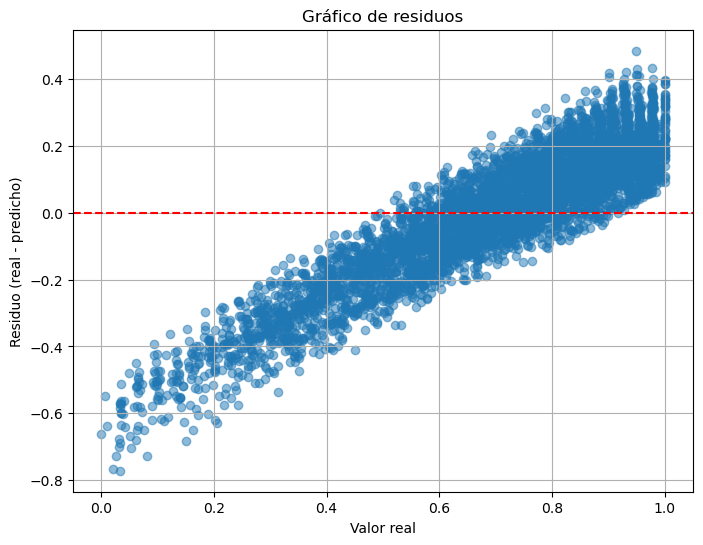

In [38]:
residuos = val_y - pred
plt.figure(figsize=(8,6))
plt.scatter(val_y, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valor real')
plt.ylabel('Residuo (real - predicho)')
plt.title('Gráfico de residuos')
plt.grid()
plt.show()

La correlación positiva indica que a medida que el valor real aumenta el error (real - predicho) también tiende a aumentar.

Es decir:

* Para valores reales bajos, el modelo tiende a sobreestimar (los residuos son negativos: predicho > real).
* Para valores reales altos, el modelo tiende a subestimar (los residuos son positivos: predicho < real).

En otras palabras, el modelo "aplana" las predicciones: no llega bien a los extremos y tiende a predecir valores más cercanos a la media.

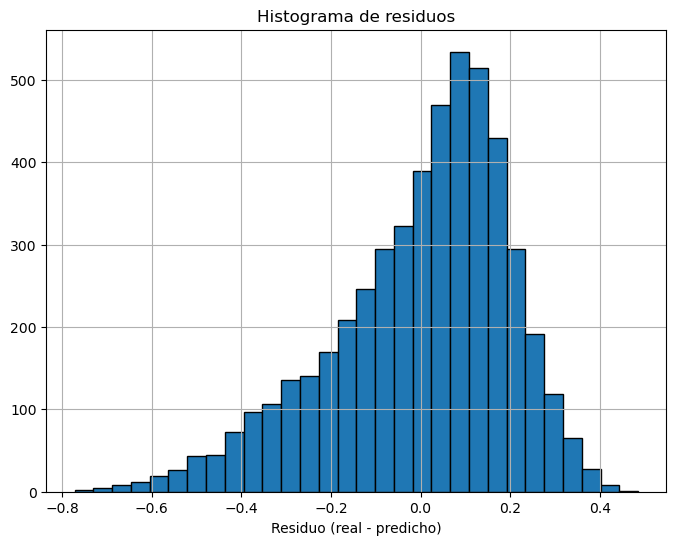

In [39]:
plt.figure(figsize=(8,6))
plt.hist(residuos, bins=30, edgecolor='k')
plt.xlabel('Residuo (real - predicho)')
plt.title('Histograma de residuos')
plt.grid()
plt.show()

El histograma está centrado ligeramente a la derecha de 0 lo que indica que el modelo tiende a subestimar ligeramente los valores reales.

La mayoría de los residuos están entre -0.4 y 0.2, lo que indica que la mayoría de los errores no son extremos.

Es decir no son errores muy grandes pero están ligeramente sesgados hacia subestimar (en caso de impago la pérdida real sería algo superior a la predicha)

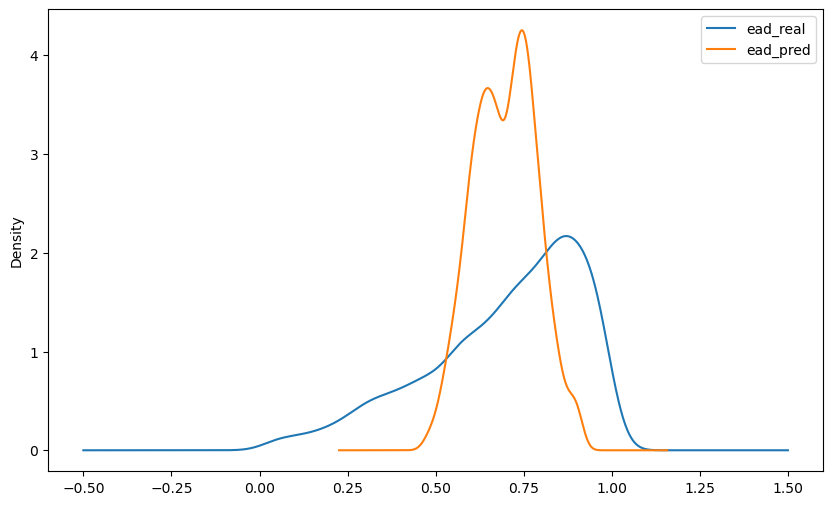

In [40]:
check_validacion.plot.density(figsize = (10,6));

En este gráfico se ven claramente:

* la tendencia hacia la media dejando los extremos más desatendidos
* el ligero sesgo hacia que la realidad sea ligeramente superior a las predicciones